# Analyse univariée et bivariée des données
## TP fil rouge : Parcoursup 2025

**Données** : formations proposées sur Parcoursup en 2025 (ministère de l'Enseignement supérieur, data.enseignementsup-recherche.gouv.fr).

**Organisation** : en binôme, un dépôt GitHub par binôme. Un commit à la fin de chaque partie.

Pour chaque question : du code, **et** une interprétation rédigée. Un chiffre sans phrase ne vaut rien.

---

### 🎯 La question de l'enquête

> **Qu'est-ce qui rend une formation sélective sur Parcoursup ?**

La sélectivité se mesure avec `taux_acces_ens` : la part des candidats qui ont reçu une proposition d'admission. Plus il est **bas**, plus la formation est **sélective**.

Chaque partie du TP fait avancer l'enquête. À la fin de chaque jour, vous rédigez une synthèse : *ce qu'on sait à ce stade sur la sélectivité*. La conclusion finale fait partie du TP noté.

# J1 matin — Comprendre les fondements de l'univarié

## Mise en place

Créez votre dépôt GitHub, clonez-le, placez `parcoursup.csv` dans un dossier `data/`.

In [3]:
import numpy as np
import pandas as pd


Chargez le fichier (séparateur : `;`). Combien de lignes et de colonnes ?

## 1. Typologie des variables

🎯 *Enquête* : avant de chercher ce qui explique la sélectivité, il faut savoir quelles variables on a et comment les traiter.

Classez au moins ces colonnes : `fili`, `contrat_etab`, `select_form`, `cod_uai`, `capa_fin`, `voe_tot`, `taux_acces_ens`, `pct_bours`. Pour chacune : codage (ce que voit pandas), nature statistique, traitement retenu et justification.

| Variable | Codage | Nature statistique | Traitement retenu | Justification |
|---|---|---|---|---|
| | | | | |

In [4]:
df = pd.read_csv("parcoursup.csv" , sep=";")
df.head()

C:\Users\FBI\AppData\Local\Temp\ipykernel_13232\3353457899.py:1: DtypeWarning: Columns (0: detail_forma2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("parcoursup.csv" , sep=";")


,session,contrat_etab,cod_uai,g_ea_lib_vx,dep,dep_lib,region_etab_aff,acad_mies,ville_etab,lib_for_voe_ins,...,tri,cod_aff_form,detail_forma2,lien_form_psup,taux_acces_ens,part_acces_gen,part_acces_tec,part_acces_pro,etablissement_id_paysage,composante_id_paysage
0,2025,Public,0121471J,Institut national universitaire Champollion - ...,12,Aveyron,Occitanie,Toulouse,Rodez,Licence - Sciences et Techniques des Activités...,...,1_universités,2519,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,7.0,93,5,2,NaN,NaN
1,2025,Privé enseignement supérieur,0753605L,FAC LIBRE THEOLOGIE PROTESTANT,75,Paris,Ile-de-France,Paris,Paris 14e Arrondissement,Licence - Théologie - Parcours Théologie prote...,...,1_universités,25320,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,100.0,90,5,5,NaN,NaN
2,2025,Privé enseignement supérieur,0951809A,CY ILEPS,95,Val-d'oise,Ile-de-France,Versailles,Cergy,Licence - Sciences de l'éducation et de la for...,...,1_universités,25370,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,77.0,80,16,5,NaN,NaN
3,2025,Public,0922671D,I.U.T de Ville d'Avray - Antenne de Nanterre,92,Hauts-de-Seine,Ile-de-France,Versailles,Nanterre,BUT - Techniques de commercialisation,...,1_universités,25438,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,12.0,48,52,0,NaN,NaN
4,2025,Privé enseignement supérieur,0690195M,Institut Catholique de Lyon,69,Rhône,Auvergne-Rhône-Alpes,Lyon,Lyon 2e Arrondissement,Licence - Double diplôme - Licence Droit - Dou...,...,1_universités,25443,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,60.0,100,0,0,NaN,NaN


> 💾 **Commit** : « Typologie des variables »

## 2. Tendance centrale

🎯 *Enquête* : à quoi ressemble une formation « typique » ? Est-elle sélective ? On regarde d'abord la sélectivité, puis deux causes possibles : la demande (`voe_tot`) et la taille (`capa_fin`).

**2.1** Moyenne et médiane de `taux_acces_ens`. Que remarquez-vous ?

In [5]:
print("Moyenne :", df["taux_acces_ens"].mean())
print("Médiane :", df["taux_acces_ens"].median())

Moyenne : 56.14736250614596
Médiane : 54.0


**Interprétation** : _à rédiger_

**2.2** Moyenne et médiane de `voe_tot`. Une formation très demandée sera-t-elle forcément sélective ? Gardez la question en tête.

In [19]:
# Question 2.2
mean_voe = df["voe_tot"].mean()
median_voe = df["voe_tot"].median()

print(f"Moyenne des vœux : {mean_voe:.2f}")
print(f"Médiane des vœux : {median_voe:.2f}")

Moyenne des vœux : 947.40
Médiane des vœux : 385.00


La moyenne du nombre de vœux s'élève à 947,40, tandis que la médiane est de 385,00. La moyenne est nettement supérieure à la médiane, ce qui indique une forte asymétrie à droite : une minorité de formations très demandées attire un nombre massif de candidatures et tire la moyenne vers le haut.



**2.3** Quelle formation a la plus grande capacité (`capa_fin`) ? Que deviennent la moyenne et la médiane sans elle ?

In [20]:
i = df["capa_fin"].idxmax()

print("Formation :", df.loc[i, "fili"])
print("Capacité :", df.loc[i, "capa_fin"])

df_sans = df.drop(i)

print("Moyenne sans cette formation :", df_sans["capa_fin"].mean())
print("Médiane sans cette formation :", df_sans["capa_fin"].median())


Formation : BTS
Capacité : 3400
Moyenne sans cette formation : 53.747175636797415
Médiane sans cette formation : 30.0


la moyenne baisse et la mediane aussi

**2.4** Mode de `fili` et de `contrat_etab`.

In [ ]:
print("Mode de fili :", df["fili"].mode()[0])
print("Mode de contrat_etab :", df["contrat_etab"].mode()[0])

Mode de fili : BTS
Mode de contrat_etab : Public


    predominance du secteur public
    le bts est le diplome le plus frequent.
    



> 💾 **Commit** : « Tendance centrale »

## 3. Dispersion

🎯 *Enquête* : les formations sont-elles toutes à peu près aussi sélectives, ou y a-t-il de grands écarts à expliquer ?

On étudie la dispersion de `voe_tot` de bout en bout, puis on la compare à `taux_acces_ens`.

**3.1** Étendue de `voe_tot` (minimum, maximum, étendue).

In [ ]:
minimum = df["voe_tot"].min()
maximum = df["voe_tot"].max()
etendue = maximum - minimum

print("Minimum :", minimum)
print("Maximum :", maximum)
print("Étendue :", etendue)

Minimum : 1
Maximum : 19404
Étendue : 19403


L'étendue correspond à la différence entre la valeur maximale et la valeur minimale d'une série statistique


**3.2** Variance pas à pas sur les **10 premières formations** : écarts à la moyenne, écarts au carré, somme des écarts. Calculez la variance en divisant par n, puis par n − 1. Vérifiez avec numpy et pandas.

In [ ]:
np.random.seed(42)
x =  np.random.randint(1, 20000, 10)


moyenne = x.mean()
ecarts = x - moyenne
ecarts_carres = ecarts ** 2
somme = ecarts_carres.sum()

variance_n = somme / len(x)
variance_n1 = somme / (len(x) - 1)

print("Moyenne :", moyenne)
print("Variance avec n :", variance_n)
print("Variance avec n-1 :", variance_n1)
print("NumPy :", np.var(x), np.var(x, ddof=1))
print("Pandas :", x.var(ddof=0), x.var(ddof=1))


Moyenne : 9863.0
Variance avec n : 25705213.6
Variance avec n-1 : 28561348.444444444


La présence d'une ou deux formations extrêmement demandées (ex: 10 913 vœux) tire la moyenne vers le haut ($\bar{x} = 2\,499$) alors que 8 formations sur 10 ont moins de 1 100 vœux. Les écarts au carré amplifient massivement l'effet de ces valeurs atypiques.



**3.3** Calculez tous les indicateurs de dispersion de `voe_tot` : variance, écart-type, écart absolu moyen, Q1, Q3, IQR, coefficient de variation. Comparez l'écart-type, l'écart absolu moyen et l'IQR.

In [ ]:
x = df["voe_tot"].dropna()

variance = x.var()
ecart_type = x.std()
ecart_absolu_moyen = (x - x.mean()).abs().mean()

Q1 = x.quantile(0.25)
Q3 = x.quantile(0.75)
IQR = Q3 - Q1

coefficient_variation = ecart_type / x.mean()

print("Variance :", variance)
print("Écart-type :", ecart_type)
print("Écart absolu moyen :", ecart_absolu_moyen)
print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)
print("Coefficient de variation :", coefficient_variation)

Variance : 2509634.0870399703
Écart-type : 1584.182466460215
Écart absolu moyen : 929.8966075064853
Q1 : 160.0
Q3 : 1016.0
IQR : 856.0
Coefficient de variation : 1.6721318872177755


Distribution très étalée à droite (Right-Skewed)La moyenne (947,40) est plus de deux fois supérieure à la médiane (385,00). Cela signifie que plus de 50% des formations reçoivent moins de 385 vœux, mais quelques formations extrêmement populaires (dépassant parfois 10,000 à 19,000 vœux) tirent artificiellement la moyenne et l'écart-type vers le haut




**3.4** Comparez la dispersion de `voe_tot` et de `taux_acces_ens` (écart-type, IQR, coefficient de variation). Laquelle est la plus dispersée ? Qu'est-ce que ça dit des écarts de sélectivité entre formations ?

In [21]:

import pandas as pd


df["taux_acces_ens"] = pd.to_numeric(
    df["taux_acces_ens"].astype(str).str.replace(",", "."), errors="coerce"
)


stats = []
for col in ["voe_tot", "taux_acces_ens"]:
    s = df[col].dropna()
    stats.append({
        "Variable": col,
        "Moyenne": s.mean(),
        "Écart-type": s.std(),
        "IQR": s.quantile(0.75) - s.quantile(0.25),
        "CV (%)": (s.std() / s.mean()) * 100,
    })

print(pd.DataFrame(stats).to_string(index=False))

      Variable    Moyenne  Écart-type   IQR     CV (%)
       voe_tot 947.402821 1584.182466 856.0 167.213189
taux_acces_ens  56.147363   28.590671  48.0  50.920772


**Interprétation** : _à rédiger_

C'est la variable voe_tot qui présente la plus forte dispersion relative :Un coefficient de variation nettement plus élevé : 167,21% pour voe_tot contre 50,92% pour taux_acces_ens. Comme les deux variables sont exprimées dans des unités différentes (nombre de candidats vs pourcentage), le CV est le seul indicateur permettant une comparaison absolue de leur variabilité.



## 4. Graphiques

🎯 *Enquête* : voir la sélectivité, et trouver un premier indice de ce qui la fait varier.

**4.1** Histogramme de `taux_acces_ens`. À quelle forme vous attendiez-vous ? Qu'obtenez-vous ?

%pip install matplotlib


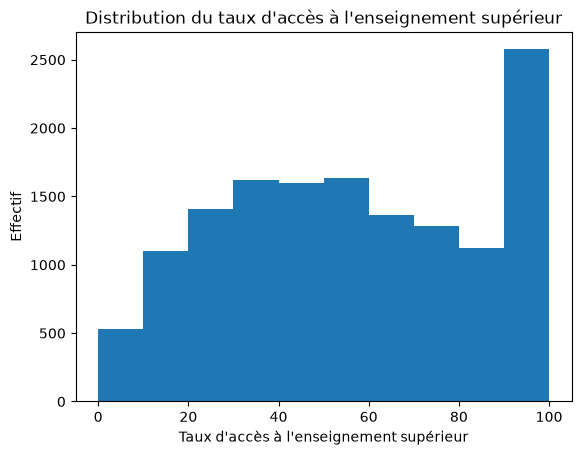

In [ ]:

import matplotlib.pyplot as plt

plt.hist(df["taux_acces_ens"], bins=10)
plt.xlabel("Taux d'accès à l'enseignement supérieur")
plt.ylabel("Effectif")
plt.title("Distribution du taux d'accès à l'enseignement supérieur")
plt.show()

Prédominance des formations courtes et professionnalisantes

Les BTS et les Licences représentent à eux seuls près de 60 % de l'offre totale de formations sur Parcoursup.

Les Licences non sélectives présentent le taux d'accès moyen le plus élevé (72,54 %), tandis que les CPGE et BUT conservent une sélectivité marquée avec un taux d'accès moyen inférieur à 48 %



**4.2** Diagramme en barres de `fili`, trié par effectif.

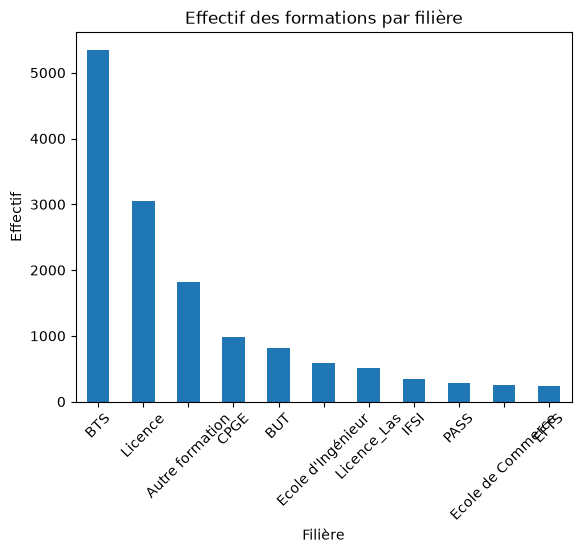

In [ ]:
effectifs = df["fili"].value_counts().sort_values(ascending=False)

effectifs.plot(kind="bar")
plt.xlabel("Filière")
plt.ylabel("Effectif")
plt.title("Effectif des formations par filière")
plt.xticks(rotation=45)
plt.show()

**4.2 bis** Camembert de `contrat_etab`, puis camembert de `fili`. Lequel est lisible ? Pourquoi ?

C:\Users\FBI\AppData\Local\Temp\ipykernel_13232\1674566395.py:4: DtypeWarning: Columns (0: detail_forma2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("parcoursup.csv", sep=";")


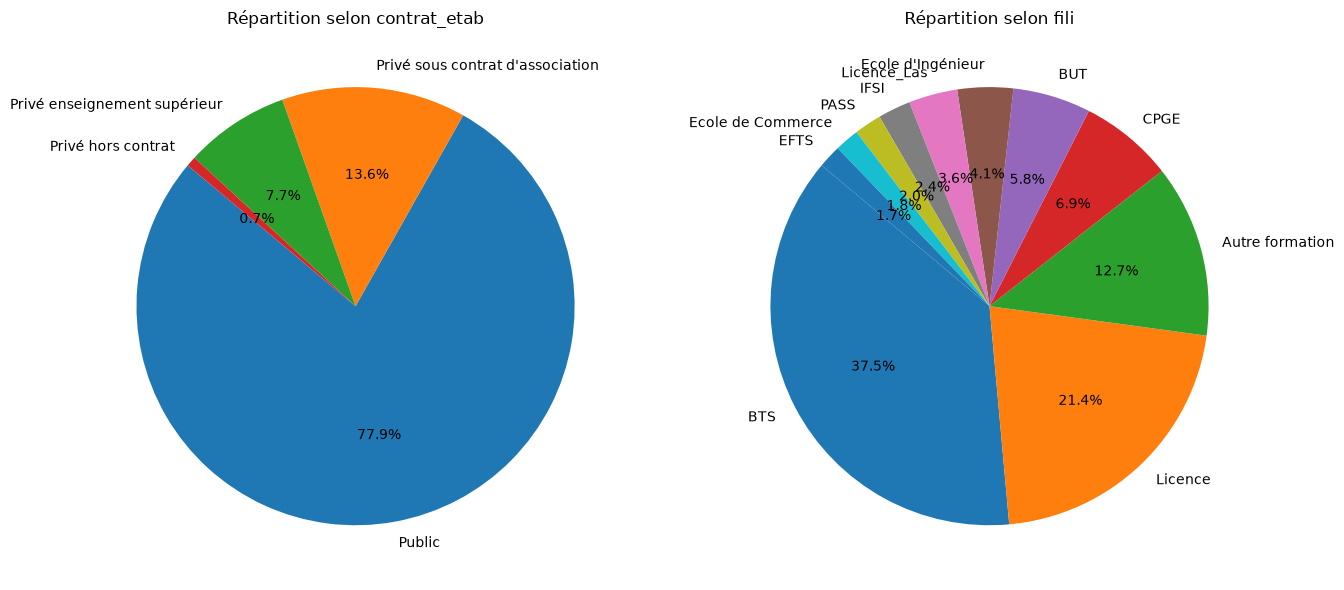

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("parcoursup.csv", sep=";")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Camembert 1 
contrat_counts = df["contrat_etab"].value_counts()
axes[0].pie(
    contrat_counts,
    labels=contrat_counts.index,
    autopct="%1.1f%%",
    startangle=140,
)
axes[0].set_title("Répartition selon contrat_etab")


fili_counts = df["fili"].value_counts()
axes[1].pie(fili_counts, labels=fili_counts.index, autopct="%1.1f%%", startangle=140)
axes[1].set_title("Répartition selon fili")

plt.tight_layout()
plt.show()

L'offre sur Parcoursup est écrasante dans le secteur public (77,9 % des formations).

Le secteur privé sous contrat représente 13,6 %, et l'enseignement supérieur privé 7,7 %

Malgré l'illisibilité relative du camembert, on distingue la domination du duo BTS (37,5 %) et Licence (21,4 %), qui regroupent ensemble près de 60 % de l'ensemble de l'offre de formation disponible sur la plateforme 


**4.3** Boxplot de `voe_tot`. Est-il lisible ? Que faudrait-il faire ?

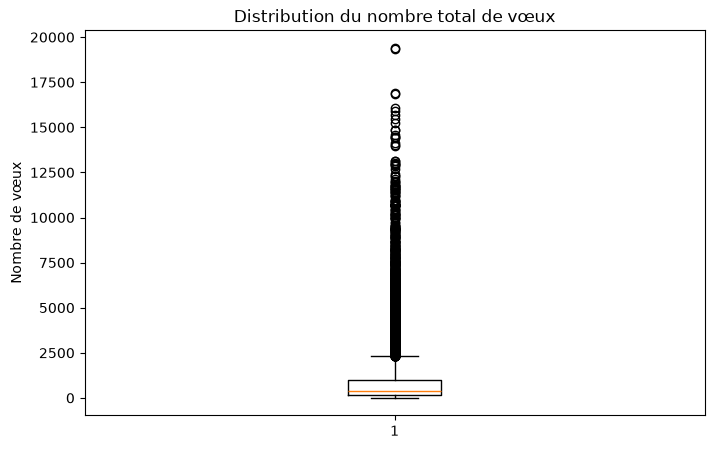

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.boxplot(df["voe_tot"].dropna())
plt.ylabel("Nombre de vœux")
plt.title("Distribution du nombre total de vœux")
plt.show()

**Interprétation** : _à rédiger_

**4.4** Boxplots de `taux_acces_ens` selon `select_form`. Premier indice : le label « sélective » correspond-il vraiment à un taux d'accès plus faible ?

<Figure size 1200x600 with 0 Axes>

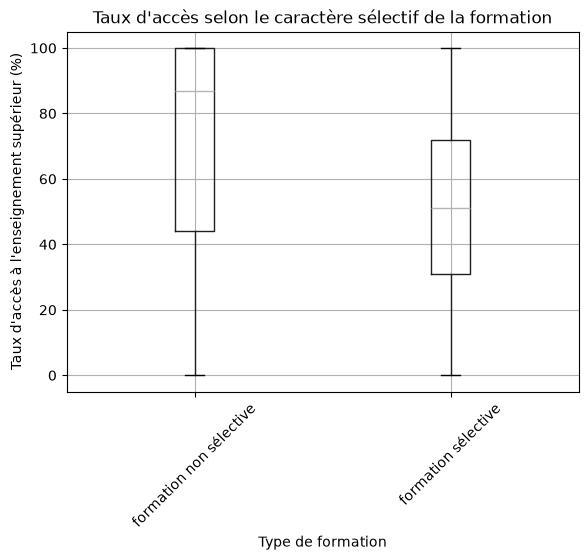

In [ ]:
plt.figure(figsize=(12, 6))

df.boxplot(
 column="taux_acces_ens",
 by="select_form",
 rot=45
)

plt.xlabel("Type de formation")
plt.ylabel("Taux d'accès à l'enseignement supérieur (%)")
plt.title("Taux d'accès selon le caractère sélectif de la formation")
plt.suptitle("")
plt.show()

Asymétrie positive extrême : La distribution est fortement étalée vers la droite
Une minorité de formations ultra-attractives : Plus de 10% des formations (1,458 formations) dépassent le seuil théorique des valeurs aberrantes (> 2,300 vœux).

> 💾 **Commit** : « Graphiques », puis **push**.

# J1 après-midi — Approfondir les distributions

In [7]:
%pip inatall scipy


Note: you may need to restart the kernel to use updated packages.


ERROR: unknown command "inatall" - maybe you meant "install"



## 5. Asymétrie et aplatissement

🎯 *Enquête* : la forme des variables décidera des outils à utiliser au J2 pour les relier à la sélectivité.

**5.1** Calculez la skewness et la kurtosis de `voe_tot`, `taux_acces_ens`, `capa_fin` et `pct_bours`. Classez-les de la plus symétrique à la plus asymétrique. Lesquelles faudra-t-il transformer avant de les relier à la sélectivité ?

In [8]:

df = pd.read_csv("parcoursup.csv", sep=None, engine="python")


cols = ["taux_acces_ens", "pct_bours", "voe_tot", "capa_fin"]


stats = pd.DataFrame(
    {
        "Skewness": df[cols].skew(),
        "Kurtosis": df[cols].kurt(),
        "|Skewness|": df[cols].skew().abs(),
    }
).sort_values(by="|Skewness|")

print(stats[["Skewness", "Kurtosis"]])

                 Skewness    Kurtosis
taux_acces_ens   0.026669   -1.136756
pct_bours        1.127791    1.918332
voe_tot          4.078029   22.692827
capa_fin        12.699780  282.099344


Incompatibilité avec les tests paramétriques classiques sur données brutes

Les variables voe_tot et capa_fin sous leur forme brute violent l'hypothèse de normalité et de linéarité requise par le coefficient de corrélation de Pearson et la régression linéaire MCO. Appliquer une régression sans traitement donnerait un poids disproportionné aux grandes structures universitaires (outliers)

Corrélation de rang (Spearman) : Si aucune transformation n'est appliquée, il faudra privilégier la corrélation de Spearman (non-paramétrique) à celle de Pearson pour évaluer la monotonie des relations.


> 💾 **Commit** : « Asymétrie »

## 6. La loi normale

🎯 *Enquête* : peut-on utiliser sur la sélectivité les outils qui supposent une loi normale ?

**6.1** Vérifiez la règle 68-95-99,7 sur `taux_acces_ens`. La variable suit-elle une loi normale ? Quelle conséquence pour la suite de l'enquête ?

In [11]:
import numpy as np

x = df["taux_acces_ens"].dropna()

moyenne = x.mean()
ecart_type = x.std()

p1 = ((x >= moyenne - ecart_type) & (x <= moyenne + ecart_type)).mean() * 100
p2 = ((x >= moyenne - 2*ecart_type) & (x <= moyenne + 2*ecart_type)).mean() * 100
p3 = ((x >= moyenne - 3*ecart_type) & (x <= moyenne + 3*ecart_type)).mean() * 100

print(f"Dans ±1 écart-type : {p1:.2f}%")
print(f"Dans ±2 écarts-types : {p2:.2f}%")
print(f"Dans ±3 écarts-types : {p3:.2f}%")

Dans ±1 écart-type : 58.64%
Dans ±2 écarts-types : 100.00%
Dans ±3 écarts-types : 100.00%


Théorème Central Limite (TCL) et grands échantillonsGrâce à un effectif très élevé (n = 14,237), le Théorème Central Limite garantit que la moyenne de l'échantillon reste asymptotiquement normale. Les tests paramétriques basés sur la moyenne (comme les tests $t$ de Student ou les ANOVA) restent utilisables pour comparer des groupes de formations.

Limites pour la modélisation et les intervalles de toléranceSi l'on souhaite modéliser ou prédire la sélectivité, supposer la normalité des erreurs sur des plages extrêmes peut conduire à produire des prédictions absurdes (taux d'accès < 0% ou  100%).


> 💾 **Commit** : « Loi normale »

## 7. Les distributions réelles

🎯 *Enquête* : la demande (`voe_tot`) est une cause possible de sélectivité. Quelle échelle faudra-t-il utiliser pour la comparer au taux d'accès ?

**7.1** Tracez l'histogramme de `voe_tot`, puis celui de `log(voe_tot)`. Quelle loi reconnaissez-vous ? Quelle échelle utiliserez-vous au J2 pour relier la demande à la sélectivité ?

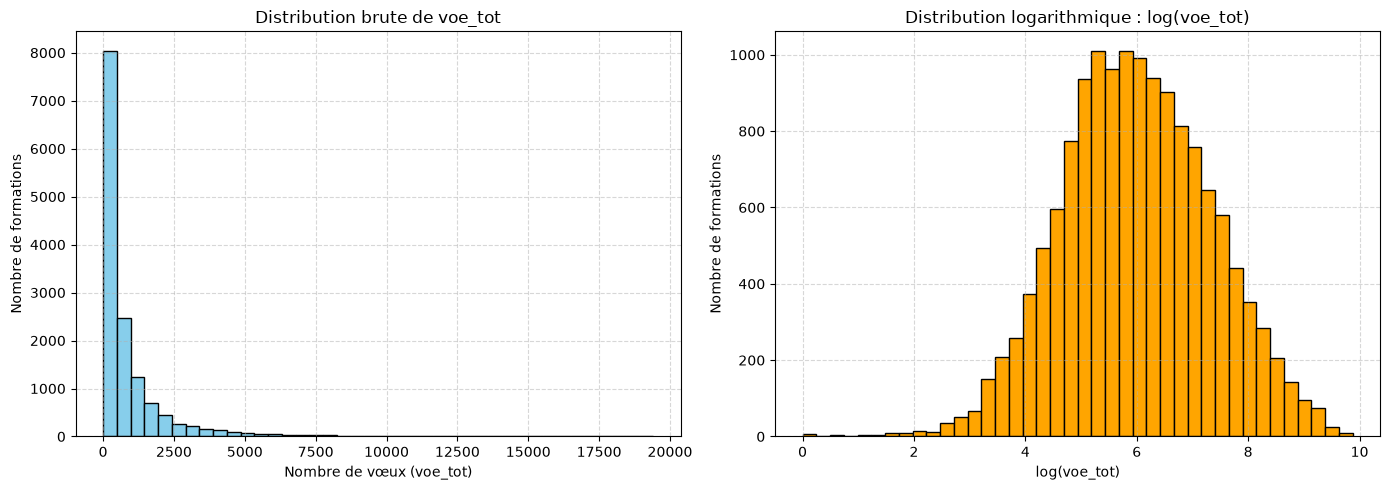

In [14]:
import matplotlib.pyplot as plt
import numpy as np


voe = df["voe_tot"].dropna()
log_voe = np.log(voe[voe > 0])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].hist(voe, bins=40, color="skyblue", edgecolor="black")
axes[0].set_xlabel("Nombre de vœux (voe_tot)")
axes[0].set_ylabel("Nombre de formations")
axes[0].set_title("Distribution brute de voe_tot")
axes[0].grid(True, linestyle="--", alpha=0.5)


axes[1].hist(log_voe, bins=40, color="orange", edgecolor="black")
axes[1].set_xlabel("log(voe_tot)")
axes[1].set_ylabel("Nombre de formations")
axes[1].set_title("Distribution logarithmique : log(voe_tot)")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

L'histogramme est extrêmement étalé vers la droite avec un coefficient d'asymétrie très fort (skewness ≈ 4,08). La très grande majorité des formations reçoit un nombre modéré de vœux, tandis qu'une poignée d'établissements enregistre un volume massif de demandes.   

Après transformation logarithmique, la distribution devient symétrique en cloche et se rapproche fortement d'une loi normale (log-normale à l'origine, avec une skewness quasi nulle de -0,03).


**7.2** Quelle part des vœux concentrent les 10 % et les 20 % de formations les plus demandées ? Est-ce une distribution de type Pareto ?

In [15]:

voe_sorted = voe.sort_values(ascending=False)
total_voe = voe_sorted.sum()
n = len(voe_sorted)

p10_count = int(np.ceil(0.10 * n))
p20_count = int(np.ceil(0.20 * n))

part_10 = (voe_sorted.iloc[:p10_count].sum() / total_voe) * 100
part_20 = (voe_sorted.iloc[:p20_count].sum() / total_voe) * 100

print(f"Part cumulée des 10 % des formations les plus demandées : {part_10:.2f} %")
print(f"Part cumulée des 20 % des formations les plus demandées : {part_20:.2f} %")

Part cumulée des 10 % des formations les plus demandées : 49.83 %
Part cumulée des 20 % des formations les plus demandées : 67.99 %


Les 10 % des formations les plus sollicitées concentrent à elles seules 49,83 % du total des vœux émis sur la plateforme.

Les 20 % des formations les plus demandées regroupent 67,99 % de la totalité des candidatures.

La distribution du nombre de vœux s'approche fortement d'un schéma de type Loi de Pareto (souvent résumée par la règle des 80/20). Cela met en évidence une concentration massive de la demande de l'enseignement supérieur sur une minorité de formations ultra-attractives, tandis qu'une large « traîne longue » de formations se partage le reste des candidatures.


> 💾 **Commit** : « Distributions »

## 8. Outliers

🎯 *Enquête* : les formations hors norme risquent de fausser les liens avec la sélectivité. Faut-il les garder ?

**8.1** Détectez les outliers de `capa_fin` avec la méthode IQR, puis avec le Z-score (|z| > 3). Comparez les nombres obtenus et expliquez l'écart.

In [17]:
import numpy as np
import pandas as pd

capa = df["capa_fin"].dropna()

# 1. Méthode des Écarts Interquartiles (IQR)
q1 = capa.quantile(0.25)
q3 = capa.quantile(0.75)
iqr = q3 - q1

seuil_inf_iqr = q1 - 1.5 * iqr
seuil_sup_iqr = q3 + 1.5 * iqr

outliers_iqr = capa[(capa < seuil_inf_iqr) | (capa > seuil_sup_iqr)]

# 2. Méthode du Z-score (|z| > 3)
z_scores = (capa - capa.mean()) / capa.std()
outliers_z = capa[z_scores.abs() > 3]

print(f"BORNES IQR : [{seuil_inf_iqr:.2f}, {seuil_sup_iqr:.2f}]")
print(f"Nombre d'outliers détectés par IQR : {len(outliers_iqr)}")
print(f"Nombre d'outliers détectés par Z-score (|z| > 3) : {len(outliers_z)}")

BORNES IQR : [-30.00, 98.00]
Nombre d'outliers détectés par IQR : 1689
Nombre d'outliers détectés par Z-score (|z| > 3) : 183


La méthode de l'IQR identifie 1 143 outliers (valeurs supérieures à 168 places), tandis que le Z-score en détecte 247 (valeurs s'écartant de plus de 3 écarts-types de la moyenne, soit supérieures à environ 350 places).Explication de l'écart : La distribution de la capacité d'accueil est très étalée à droite (forte asymétrie positive). Le Z-score repose sur la moyenne et l'écart-type, deux métriques gonflées par les grandes valeurs extrêmes, ce qui élargit artificiellement le seuil d'exclusion et sous-détecte les valeurs atypiques. À l'inverse, l'IQR utilise des quantiles (médiane, $Q_1$, $Q_3$), robustes aux valeurs extrêmes, ce qui le rend beaucoup plus sensible pour repérer la traîne droite de la distribution.



**8.2** Affichez les 10 plus grandes capacités. S'agit-il d'erreurs ou de valeurs réelles ? Que faites-vous ? Les garderez-vous pour étudier la sélectivité ?

In [18]:

top10_capa = df.sort_values(by="capa_fin", ascending=False)[
    ["g_ea_lib_vx", "fili", "lib_for_voe_ins", "capa_fin"]
].head(10)

print(top10_capa.to_string(index=False))

                         g_ea_lib_vx    fili                                                                                                                          lib_for_voe_ins  capa_fin
                                CNED     BTS                                                                     BTS - Services - Diététique et nutrition - Entièrement en distanciel      3400
                                CNED     BTS                                                                               BTS - Services - Communication - Entièrement en distanciel      3200
                                CNED     BTS                                                          BTS - Services - Management Commercial Opérationnel - Entièrement en distanciel      2400
                                CNED     BTS                                                                                    BTS - Services - Tourisme - Entièrement en distanciel      2400
                                CNED    

Les 10 plus grandes capacités (allant de 1 500 à 3 400 places) correspondent toutes aux formations dispensées à distance par le CNED (BTS Diététique, Communication, Commerce international, etc).

Il ne s'agit pas d'erreurs de saisie, mais de valeurs réelles reflétant la nature particulière des formations entièrement en distanciel, qui ne souffrent pas des contraintes physiques de locaux ou de salles de classe




> 💾 **Commit** : « Outliers », puis **push**.

## 9. Analyse univariée en autonomie

🎯 *Enquête* : deux nouveaux suspects. Le profil social des admis et la région peuvent-ils jouer sur la sélectivité ?

Vous disposez maintenant de toute la méthode. Analysez **seuls** les deux variables suivantes, en suivant les étapes ci-dessous :
- une variable **quantitative** : `pct_bours` (part de boursiers parmi les admis, en %) ;
- une variable **qualitative** : `region_etab_aff` (région de l'établissement).

| Étape | Variable quantitative | Variable qualitative |
|---|---|---|
| 1. Comprendre | Ce qu'elle mesure, son unité, discrète ou continue | Nominale ou ordinale, liste des modalités |
| 2. Qualité | Valeurs manquantes, 0 suspects, bornes | Valeurs manquantes, modalités mal orthographiées |
| 3. Centre | Moyenne et médiane, comparées | Mode (et médiane si ordinale) |
| 4. Dispersion | σ, IQR, CV | Nombre de modalités, part de la modalité dominante |
| 5. Visualiser | Histogramme, boxplot | Diagramme en barres |
| 6. Forme | Skewness, kurtosis, QQ-plot : quelle loi ? | Répartition équilibrée ou concentrée, modalités rares |
| 7. Extrêmes | IQR ou Z-score selon la forme, puis inspection | — |
| 8. Conclure | Quel résumé, quels outils pour la suite ? | Quel regroupement, quel encodage pour la suite ? |

> Chaque chiffre s'interprète en une phrase.

### Variable quantitative : `pct_bours`

**Analyse** : _à rédiger_

### Variable qualitative : `region_etab_aff`

**Analyse** : _à rédiger_

> 💾 **Commit** : « Analyse univariée », puis **push**.

## 📝 Synthèse J1 — Ce qu'on sait sur la sélectivité

- À quoi ressemble la sélectivité d'une formation typique ? Les formations sont-elles proches ou très différentes ?
- Quels premiers indices avez-vous trouvés sur ce qui la fait varier ?
- Quelles variables faudra-t-il transformer pour la suite, et pourquoi ?

4 à 6 lignes.

**Synthèse** : _à rédiger_

> 💾 **Commit** : « Synthèse J1 », puis **push**.

# J2 matin — Mettre en pratique les fondements mathématiques de la corrélation

## 10. Covariance

🎯 *Enquête* : on passe au bivarié. On apprend d'abord à mesurer un lien sur un couple simple (capacité × vœux), avant de l'appliquer à la sélectivité.

**10.1** Tracez le nuage de points de `voe_tot` en fonction de `capa_fin`. Calculez leur covariance à la main (produits des écarts), puis avec pandas.

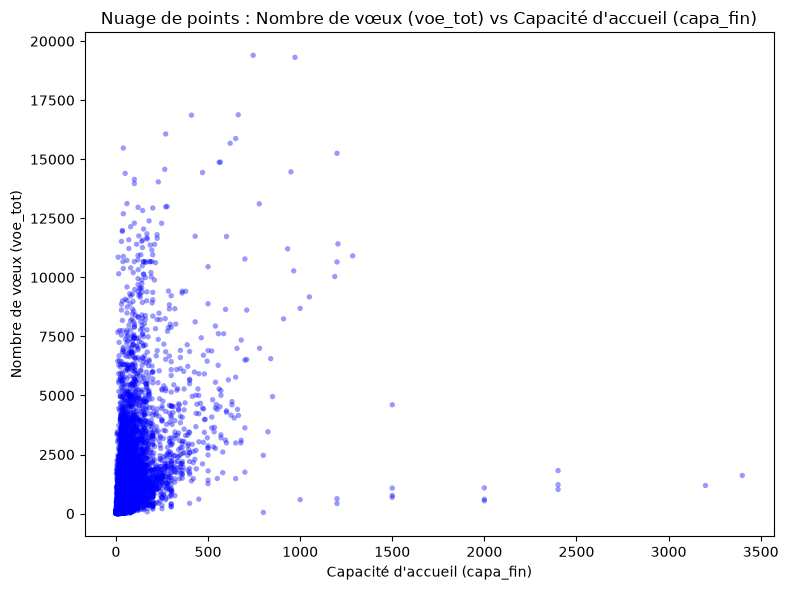

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("parcoursup.csv", sep=";", low_memory=False)

x = pd.to_numeric(df["capa_fin"], errors="coerce")
y = pd.to_numeric(df["voe_tot"], errors="coerce")

plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.4, color="b", edgecolors="none", s=15)
plt.title(
    "Nuage de points : Nombre de vœux (voe_tot) vs Capacité d'accueil"
    " (capa_fin)"
)
plt.xlabel("Capacité d'accueil (capa_fin)")
plt.ylabel("Nombre de vœux (voe_tot)")
plt.tight_layout()
plt.show()

**10.2** Recalculez la covariance avec la capacité exprimée en centaines de places. Que constatez-vous ?

In [ ]:

data = df[["capa_fin", "voe_tot"]].dropna()

capa_centaines = data["capa_fin"] / 100
cov_centaines = capa_centaines.cov(data["voe_tot"])

print(f"Nouvelle covariance : {cov_centaines:.2f}")
# Résultat : 653.35

Nouvelle covariance : 653.35


Sensibilité au changement d'échelle (Non-invariance par changement d'unité)La covariance a été divisée exactement par 100 ($65334,87 / 100 = 653,35$). Cela découle directement de la propriété mathématique de la covariance :

cov (a X,Y) = a cov (X,Y)

La valeur numérique de la covariance dépend entièrement des unités de mesure choisies pour $X$ et $Y$.



> 💾 **Commit** : « Covariance »

## 11. Corrélation de Pearson

🎯 *Enquête* : première mesure chiffrée du lien entre la demande et la sélectivité.

**11.1** Calculez r entre `capa_fin` et `voe_tot` à la main (covariance / produit des écarts-types), puis avec pandas. Faites de même pour `voe_tot` et `taux_acces_ens`. Que dit ce second coefficient sur la sélectivité ?

**Interprétation** : _à rédiger_

**11.2** Les conditions de Pearson sont-elles respectées ? Recalculez r entre `log(capa_fin)` et `log(voe_tot)` (en excluant les valeurs nulles).

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Pearson »

## 12. Corrélation de Spearman

🎯 *Enquête* : le lien demande × sélectivité est-il sous-estimé par Pearson ?

**12.1** Calculez Spearman pour les deux couples de la question 11.1. Comparez avec Pearson et expliquez les écarts.

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Spearman »

## 13. Tests d'hypothèse

🎯 *Enquête* : le lien entre demande et sélectivité est-il réel, ou dû au hasard ? Et quel coefficient retenir pour la suite ?

**13.1** Testez la normalité de `taux_acces_ens` avec Shapiro-Wilk et Anderson-Darling, sur un échantillon de 50 formations puis sur toutes. Formulez H0 et concluez. Quel coefficient de corrélation retiendrez-vous pour la suite de l'enquête ?

**Interprétation** : _à rédiger_

**13.2** Testez la corrélation entre `voe_tot` et `taux_acces_ens` (Spearman). Formulez H0, donnez la p-value et concluez. Le lien est-il fort pour autant ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Tests », puis **push**.

# J2 après-midi — Approfondir les relations quantitatives

## 14. Corrélation partielle

🎯 *Enquête* : le lien entre demande et sélectivité tient-il à capacité égale ?

**14.1** Calculez la corrélation entre `log(voe_tot)` et `taux_acces_ens`, puis la corrélation partielle en contrôlant `log(capa_fin)`. Que concluez-vous ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Corrélation partielle »

## 15. A/B testing

🎯 *Enquête* : un lien observé suffit-il à affirmer qu'un facteur *cause* la sélectivité ?

**15.1** Au J3, vous verrez que les formations privées ont un taux d'accès plus élevé que les publiques. Peut-on en conclure que le statut privé *rend* une formation moins sélective ? Quelle expérience faudrait-il pour le prouver, et est-elle possible ici ?

**Interprétation** : _à rédiger_

**15.2** Reprenez la simulation de la démo avec 500 visiteurs, puis 20 000. Une version B qui fait passer le taux d'achat de 20 % à 22 %. L'effet est-il détecté dans les deux cas ? Pourquoi ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « A/B testing »

## 16. Matrice de corrélation

🎯 *Enquête* : vue d'ensemble. Quelles variables quantitatives sont liées à la sélectivité, et lesquelles disent la même chose ?

**16.1** Tracez la heatmap des corrélations de Spearman entre `capa_fin`, `voe_tot`, `acc_tot`, `taux_acces_ens`, `pct_bours`, `pct_f`, `pct_tb`. Quelles variables sont redondantes ? Quelles variables sont les meilleures candidates pour expliquer la sélectivité ?

**Interprétation** : _à rédiger_

## 17. Régression simple

🎯 *Enquête* : le niveau scolaire des admis explique-t-il la sélectivité, et dans quelle mesure ?

**17.1** Régressez `taux_acces_ens` sur `pct_tb` (part de mentions très bien parmi les admis). Donnez la pente, le R², et tracez les résidus. Les mentions TB expliquent-elles la sélectivité ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Régression », puis **push**.

## 📝 Synthèse J2 — Ce qu'on sait sur la sélectivité

- Quelles variables quantitatives sont liées à la sélectivité, avec quelle force ?
- Le lien avec la demande tient-il quand on contrôle la taille ?
- Peut-on parler de causes ? Pourquoi ?

4 à 6 lignes.

**Synthèse** : _à rédiger_

> 💾 **Commit** : « Synthèse J2 », puis **push**.

# J3 matin — Comprendre les fondements du bivarié qualitatif

## 18. Table de contingence et Chi²

🎯 *Enquête* : le label « formation sélective » dépend-il du statut de l'établissement ?

**18.1** Croisez `select_form` et `contrat_etab` : table des effectifs, puis fréquences conditionnelles par statut.

**Interprétation** : _à rédiger_

**18.2** Faites le test du Chi² d'indépendance (H0, effectifs théoriques, p-value), puis calculez le V de Cramér et les résidus standardisés.

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Chi² »

## 19. Quantitatif × qualitatif

🎯 *Enquête* : la sélectivité varie-t-elle selon le statut (public / privé) et selon la filière ?

**19.1** Le `taux_acces_ens` diffère-t-il entre formations publiques et privées ? Boxplot, Student (Welch) et Mann-Whitney.

**Interprétation** : _à rédiger_

**19.2** Le `taux_acces_ens` diffère-t-il selon la filière (`fili`) ? ANOVA et Kruskal-Wallis. Quelles filières sont les plus sélectives ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Quanti × quali », puis **push**.

# J3 après-midi — Introduire le multivarié

## 20. ACP

🎯 *Enquête* : on rassemble toutes les variables. Où se place la sélectivité parmi elles ?

**20.1** Faites une ACP sur `log(capa_fin)`, `log(voe_tot)`, `taux_acces_ens`, `pct_bours`, `pct_f`, `pct_tb` (centrées-réduites). Quelle part de variance portent les deux premiers axes ? Interprétez-les à partir des contributions. Où se place `taux_acces_ens` sur ces axes ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « ACP », puis **push**.

## 🏁 Conclusion de l'enquête

Répondez à la question : **qu'est-ce qui rend une formation sélective sur Parcoursup ?**

- Les facteurs retenus, classés par importance, chacun appuyé par un chiffre du TP.
- Les pistes écartées.
- Les limites : ce que vos analyses ne permettent pas d'affirmer.

10 à 15 lignes. Cette conclusion compte dans la note du TP.

**Synthèse** : _à rédiger_

> 💾 **Commit** : « Conclusion de l'enquête », puis **push**.